# Fractional Derivatives and the Gaussian

The classical derivative $f'(x)$ differentiates once; $f''(x)$ twice. Can we differentiate a **non-integer number of times**? The answer is yes, and the resulting operators — **fractional derivatives** — arise naturally in anomalous diffusion, viscoelastic materials, signal processing, and potential theory.

## Fourier definition

For a function $f$ on $\mathbb{R}$, the Fourier transform converts differentiation to multiplication:
$$
\widehat{f^{(n)}}(\xi) = (2\pi i \xi)^n \hat{f}(\xi).
$$
Replacing the integer $n$ by a real $\alpha \geq 0$ gives the **fractional derivative of order $\alpha$**:
$$
\widehat{D^\alpha f}(\xi) = (2\pi i \xi)^\alpha \hat{f}(\xi),
$$
where $(i\xi)^\alpha = |\xi|^\alpha e^{i\pi\alpha \text{sign}(\xi)/2}$. This defines a **bounded operator** on $L^2$ whenever $\hat{f}$ decays fast enough.

## The Gaussian under fractional differentiation

The Gaussian $g_\sigma(x) = e^{-x^2/(2\sigma^2)}$ has Fourier transform $\hat{g}_\sigma(\xi) = \sqrt{2\pi}\,\sigma e^{-2\pi^2 \sigma^2 \xi^2}$, also Gaussian. Multiplying by $(2\pi i\xi)^\alpha$ modulates the spectrum by a power law, yielding a fractional derivative that interpolates smoothly between:
- $\alpha = 0$: the original Gaussian.
- $\alpha = 1$: the (odd) first derivative — antisymmetric.
- $\alpha = 2$: the second derivative — symmetric, one zero-crossing pair.
- $\alpha = n$: the $n$-th Hermite function (up to normalization).

## Fractional Laplacian

The related **fractional Laplacian** $(-\Delta)^{s/2}$ is defined by $\widehat{(-\Delta)^{s/2} f}(\xi) = (2\pi|\xi|)^s \hat{f}(\xi)$ and provides the symmetric (non-directional) version.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Fractional derivatives on the grid

We use the DFT to compute fractional derivatives on a periodic grid. The operator is defined by multiplying the Fourier coefficients by $(2\pi i k)^\alpha$, where $k$ are the integer frequencies.

In [2]:
n = 4096
t = np.linspace(-1, 1, n, endpoint=False)

# Fourier frequencies (integer, centered)
om = np.fft.fftfreq(n) * n

def frac_deriv(f, alpha):
    """Fractional derivative of order alpha via FFT.
    Uses (2*pi*i*k)^alpha = (2*pi*|k|)^alpha * exp(i*alpha*pi/2*sign(k))
    """
    F = np.fft.fft(f)
    abs_om = np.abs(om)
    phase = np.exp(1j * alpha * np.pi / 2 * np.sign(om))
    kernel = (abs_om ** alpha) * phase
    kernel[0] = 0  # zero mean
    return np.real(np.fft.ifft(F * kernel))


def frac_laplacian(f, s):
    """Fractional Laplacian (-Delta)^{s/2}: symmetric operator."""
    F = np.fft.fft(f)
    kernel = np.abs(om) ** s
    kernel[0] = 0
    return np.real(np.fft.ifft(F * kernel))


print('Fractional derivative tools ready.')

Fractional derivative tools ready.


## The Gaussian under varying fractional order

We apply the fractional derivative to a narrow Gaussian and display the result for $\alpha \in [0, 4]$. Notice:
- $\alpha = 0$: Gaussian (symmetric).
- $\alpha = 1$: antisymmetric, one zero-crossing at the origin.
- $\alpha = 2$: symmetric, two zero-crossings (second derivative).
- Non-integer $\alpha$: intermediate shapes with complex oscillation patterns.

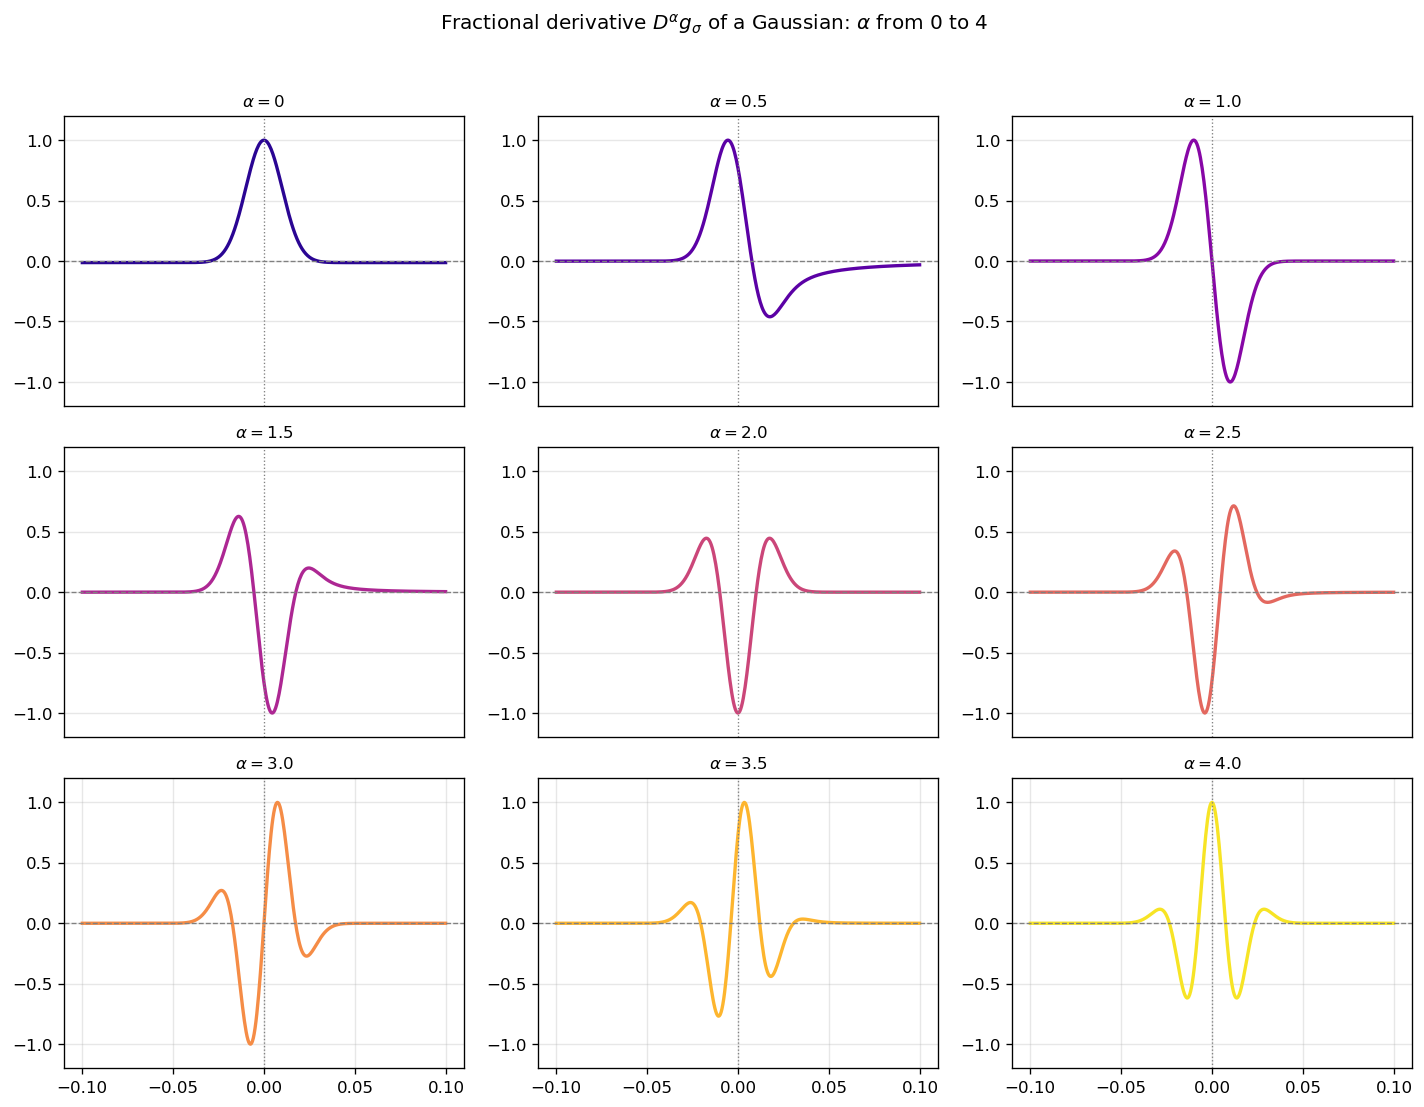

In [3]:
sigma = 0.01
f_gauss = np.exp(-t**2 / (2 * sigma**2))

alpha_values = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
cols = plt.cm.plasma(np.linspace(0.05, 0.95, len(alpha_values)))

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, alpha, col in zip(axes.ravel(), alpha_values, cols):
    Df = frac_deriv(f_gauss, alpha)
    Df_norm = Df / (np.max(np.abs(Df)) + 1e-14)
    x_zoom = 0.1
    mask = np.abs(t) < x_zoom
    ax.plot(t[mask], Df_norm[mask], lw=2, color=col)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_title(fr'$\alpha = {alpha}$', fontsize=10)
    ax.set_ylim(-1.2, 1.2); ax.grid(alpha=0.3)
    if ax.get_subplotspec().rowspan.start < 2: ax.set_xticks([])

fig.suptitle(r'Fractional derivative $D^\alpha g_\sigma$ of a Gaussian: $\alpha$ from 0 to 4', y=1.02)
plt.tight_layout()
plt.show()

## Spectral interpretation

In Fourier space, the fractional derivative multiplies by a power law: $|\xi|^\alpha$. We display the amplitude spectrum of $D^\alpha g$ and verify that it equals $|\xi|^\alpha \cdot |\hat{g}(\xi)|$.

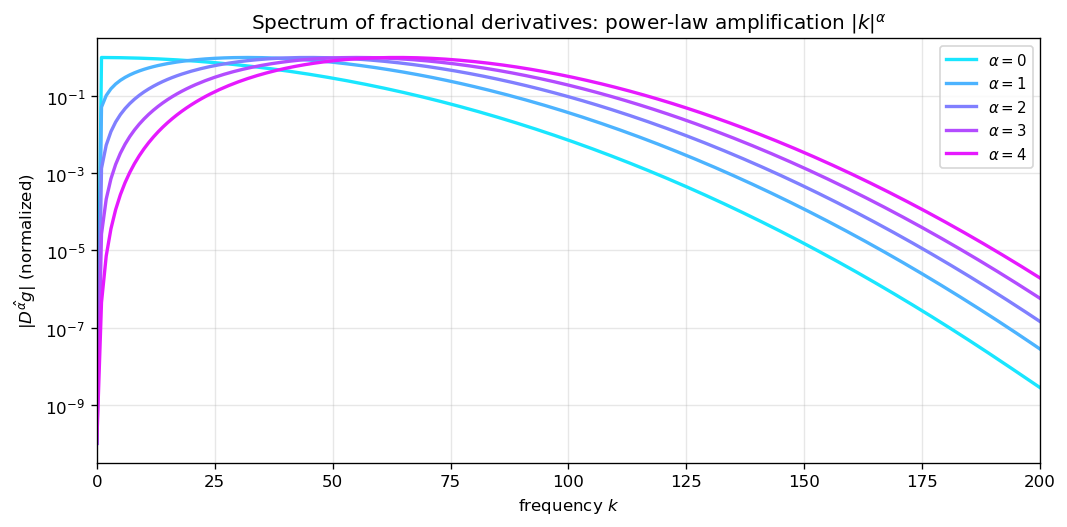

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))

F_gauss = np.fft.fft(f_gauss)
m = n // 4  # show only positive frequencies
k_pos = om[:m]

for alpha, col in zip([0, 1, 2, 3, 4], plt.cm.cool(np.linspace(0.1, 0.9, 5))):
    Df = frac_deriv(f_gauss, alpha)
    F_Df = np.abs(np.fft.fft(Df)[:m])
    F_Df_norm = F_Df / (F_Df.max() + 1e-14)
    ax.semilogy(k_pos, F_Df_norm + 1e-10, lw=2, color=col, label=fr'$\alpha={alpha}$')

ax.set_xlabel('frequency $k$'); ax.set_ylabel('$|\\hat{D^\\alpha g}|$ (normalized)')
ax.set_title('Spectrum of fractional derivatives: power-law amplification $|k|^\\alpha$')
ax.set_xlim(0, 200); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fractional Laplacian: symmetric version

The fractional Laplacian $(-\Delta)^{s/2}$ is isotropic (rotationally symmetric) and arises in L\'evy diffusion, nonlocal PDEs, and the Caffarelli–Silvestre extension. For the Gaussian it produces symmetric shapes for all $s$.

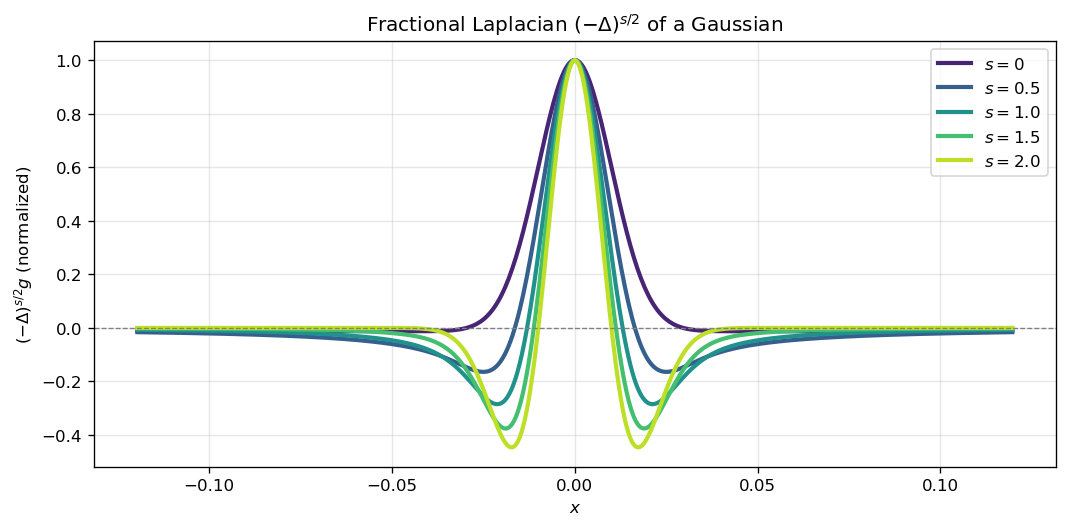

In [5]:
s_values = [0, 0.5, 1.0, 1.5, 2.0]
cols_l = plt.cm.viridis(np.linspace(0.1, 0.9, len(s_values)))

fig, ax = plt.subplots(figsize=(9, 4.5))
x_zoom = 0.12; mask = np.abs(t) < x_zoom
for s, col in zip(s_values, cols_l):
    Lf = frac_laplacian(f_gauss, s)
    Lf_norm = Lf / (np.max(np.abs(Lf)) + 1e-14)
    ax.plot(t[mask], Lf_norm[mask], lw=2.5, color=col, label=fr'$s={s}$')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('$x$'); ax.set_ylabel('$(-\\Delta)^{s/2} g$ (normalized)')
ax.set_title(r'Fractional Laplacian $(-\Delta)^{s/2}$ of a Gaussian')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive: sweep $\alpha$ continuously

Drag the slider to watch the Gaussian deform continuously from $\alpha = 0$ (itself) through integer derivative orders.

In [6]:
def show_frac_der(alpha=1.0):
    Df = frac_deriv(f_gauss, alpha)
    Df_norm = Df / (np.max(np.abs(Df)) + 1e-14)
    x_zoom = 0.12; mask = np.abs(t) < x_zoom
    t_col = alpha / 4.0
    col = (t_col, 0, 1 - t_col)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(t[mask], Df_norm[mask], lw=2.5, color=col)
    axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$D^\\alpha g$ (normalized)')
    axes[0].set_title(fr'$D^{{\alpha={alpha:.2f}}} g_\sigma$'); axes[0].grid(alpha=0.3)

    F = np.fft.fft(Df); m = n//4; k_p = om[:m]
    F_norm = np.abs(F[:m]) / (np.abs(F[:m]).max() + 1e-14)
    axes[1].semilogy(k_p, F_norm + 1e-12, lw=2, color=col)
    axes[1].set_xlabel('frequency $k$'); axes[1].set_ylabel('$|\\hat{D^\\alpha g}|$')
    axes[1].set_title('Fourier amplitude')
    axes[1].set_xlim(0, 300); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_frac_der,
         alpha=FloatSlider(value=1.0, min=0.0, max=4.0, step=0.1,
                           description=r'$\alpha$'));

interactive(children=(FloatSlider(value=1.0, description='$\\alpha$', max=4.0), Output()), _dom_classes=('widg…

## Bibliographical resources

- Liouville, J. (1832). Mémoire sur quelques questions de géométrie et de mécanique. *Journal de l'École Polytechnique*, 13, 1–69.
- Riesz, M. (1949). L'intégrale de Riemann–Liouville et le problème de Cauchy. *Acta Mathematica*, 81, 1–223.
- Samko, S. G., Kilbas, A. A. and Marichev, O. I. (1993). *Fractional Integrals and Derivatives*. Gordon and Breach.
- Caffarelli, L. and Silvestre, L. (2007). An extension problem related to the fractional Laplacian. *Communications in Partial Differential Equations*, 32(8), 1245–1260.
- Pozrikidis, C. (2016). *The Fractional Laplacian*. CRC Press.